In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, auc

df= pd.read_csv("CAR_DEKHO.csv" , encoding="ISO-8859-1")

In [2]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [4]:
df.describe()

,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


In [5]:
df.isnull().sum()

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

In [6]:
df.nunique()

name             1491
year               27
selling_price     445
km_driven         770
fuel                5
seller_type         3
transmission        2
owner               5
dtype: int64

In [13]:
df["is_expensive"]= (df["selling_price"] >=300000).astype(int)
df= df.drop(columns=["name","selling_price"])
df_encoding= pd.get_dummies(df, drop_first= True)
X= df_encoding.drop(columns= ["is_expensive"])
y= df_encoding["is_expensive"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
tree_clf = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_clf.fit(X_train, y_train)
tree_preds = tree_clf.predict(X_test
                             )
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
log_preds = logreg.predict(X_test)


C:\Users\hp\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [17]:
tree_acc = accuracy_score(y_test, tree_preds)
tree_cm = confusion_matrix(y_test, tree_preds)

log_acc = accuracy_score(y_test, log_preds)
log_cm = confusion_matrix(y_test, log_preds)

In [18]:
# Print Results
print("======== DECISION TREE =========")
print(f"Accuracy: {tree_acc:.2f}")
print("Confusion Matrix:")
print(tree_cm)
print("Classification Report:")
print(classification_report(y_test, tree_preds))

======== DECISION TREE =========
Accuracy: 0.83
Confusion Matrix:
[[293  57]
 [ 90 428]]
Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.84      0.80       350
           1       0.88      0.83      0.85       518

    accuracy                           0.83       868
   macro avg       0.82      0.83      0.83       868
weighted avg       0.84      0.83      0.83       868



In [19]:
print("\n======== LOGISTIC REGRESSION =========")
print(f"Accuracy: {log_acc:.2f}")
print("Confusion Matrix:")
print(log_cm)
print("Classification Report:")
print(classification_report(y_test, log_preds))


======== LOGISTIC REGRESSION =========
Accuracy: 0.75
Confusion Matrix:
[[202 148]
 [ 65 453]]
Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.58      0.65       350
           1       0.75      0.87      0.81       518

    accuracy                           0.75       868
   macro avg       0.76      0.73      0.73       868
weighted avg       0.75      0.75      0.75       868



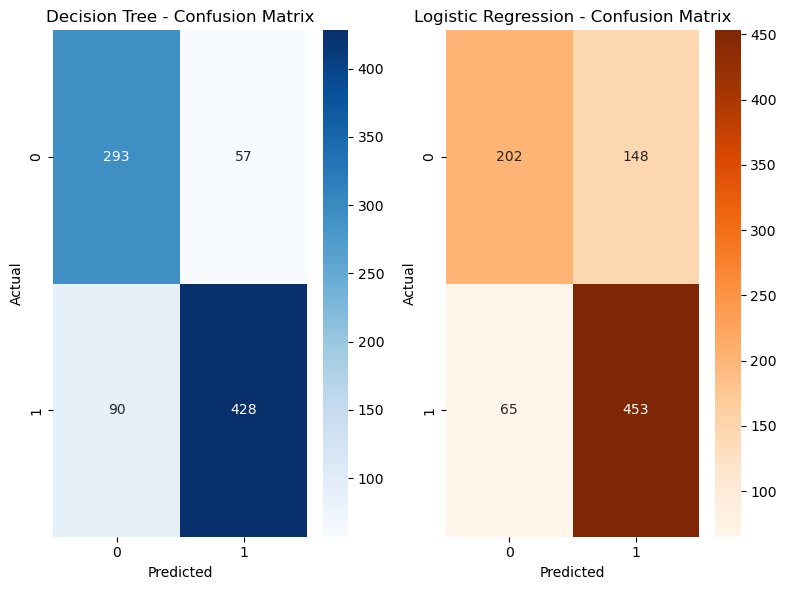

In [20]:
# Plotting

tree_cm = confusion_matrix(y_test, tree_preds)
tree_probs = tree_clf.predict_proba(X_test)[:, 1]

log_cm = confusion_matrix(y_test, log_preds)
log_probs = logreg.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(8, 6))


# Decision Tree Confusion Matrix
sns.heatmap(tree_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("Decision Tree - Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")


# Logistic Regression Confusion Matrix
sns.heatmap(log_cm, annot=True, fmt='d', cmap='Oranges', ax=axes[1])
axes[1].set_title("Logistic Regression - Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

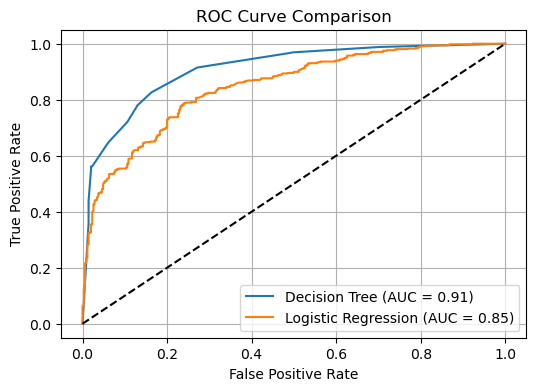

(0.9091092112520684, 0.8457308328736901)

In [21]:
# ROC Curve

fpr_tree, tpr_tree, _ = roc_curve(y_test, tree_probs)
fpr_log, tpr_log, _ = roc_curve(y_test, log_probs)

auc_tree = auc(fpr_tree, tpr_tree)
auc_log = auc(fpr_log, tpr_log)


# Plot ROC Curves
plt.figure(figsize=(6, 4))

plt.plot(fpr_tree, tpr_tree, label=f"Decision Tree (AUC = {auc_tree:.2f})")
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {auc_log:.2f})")

plt.plot([0, 1], [0, 1], 'k--')  # Random baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()
plt.grid(True)
plt.show()

auc_tree, auc_log